# 4. Multi-Qubit Systems

This notebook explores circuits with more than one qubit, including
**entanglement** — a special quantum correlation between qubits that
has no classical equivalent.

## Step 1: Import libraries

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_distribution, plot_histogram

simulator = AerSimulator()

## Bell state (2-qubit entanglement)

Steps: put qubit 0 into superposition with H, then use a CNOT (CX)
gate so qubit 1's state becomes linked to qubit 0's state.

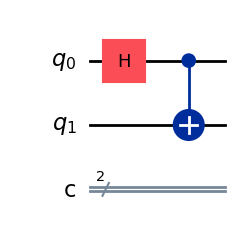

In [2]:
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
qc_bell.draw("mpl")

Bell state probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


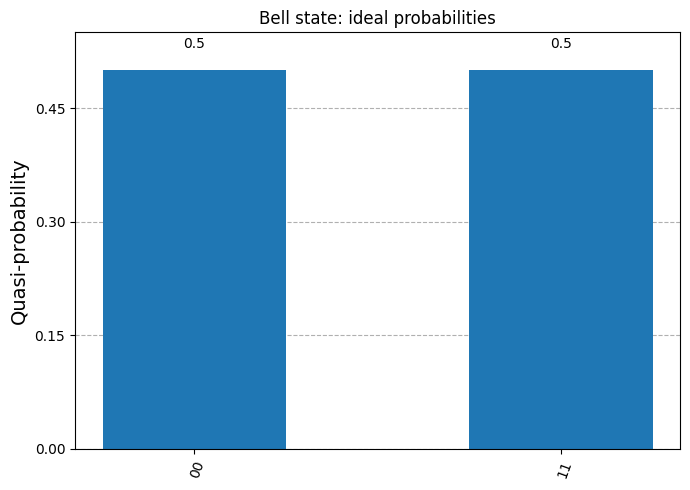

In [3]:
probs_bell = Statevector(qc_bell).probabilities_dict()
print("Bell state probabilities:", probs_bell)
plot_distribution(probs_bell, title="Bell state: ideal probabilities")

Bell state measurement counts: {'11': 506, '00': 518}


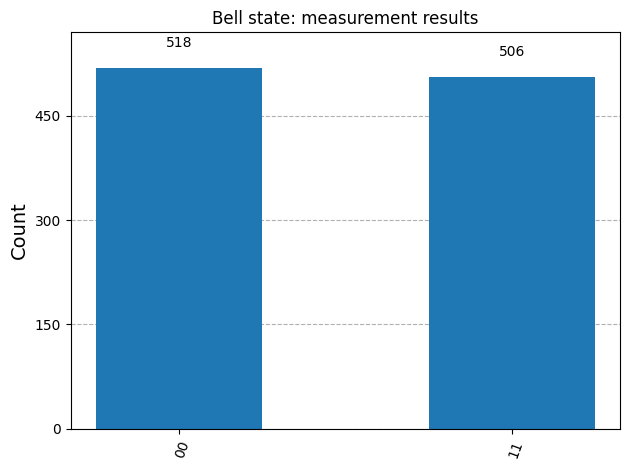

In [4]:
qc_bell.measure([0, 1], [0, 1])
counts_bell = simulator.run(transpile(qc_bell, simulator), shots=1024).result().get_counts()
print("Bell state measurement counts:", counts_bell)
plot_histogram(counts_bell, title="Bell state: measurement results")

Notice you only ever see `'00'` or `'11'` — never `'01'` or `'10'`.
The two qubits are entangled: measuring one instantly tells you the
other's result, no matter how far apart they are.

## GHZ state (3-qubit entanglement)

The same idea extended to three qubits.

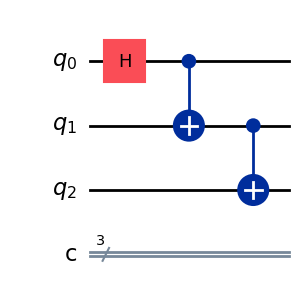

In [5]:
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)
qc_ghz.draw("mpl")

GHZ state probabilities: {np.str_('000'): np.float64(0.4999999999999999), np.str_('111'): np.float64(0.4999999999999999)}


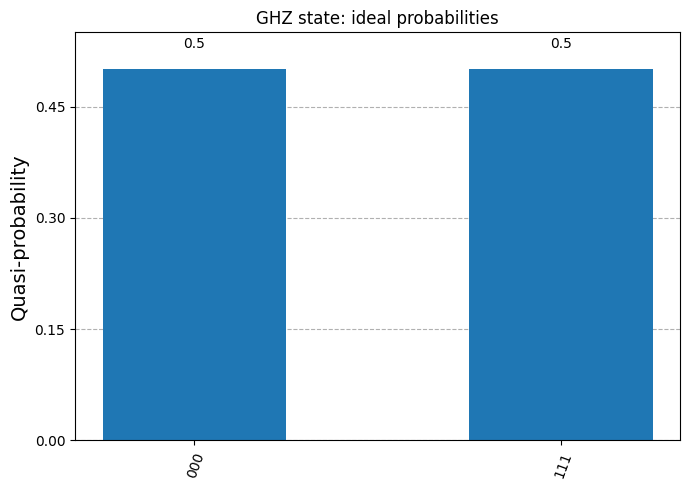

In [6]:
probs_ghz = Statevector(qc_ghz).probabilities_dict()
print("GHZ state probabilities:", probs_ghz)
plot_distribution(probs_ghz, title="GHZ state: ideal probabilities")

GHZ state measurement counts: {'111': 494, '000': 530}


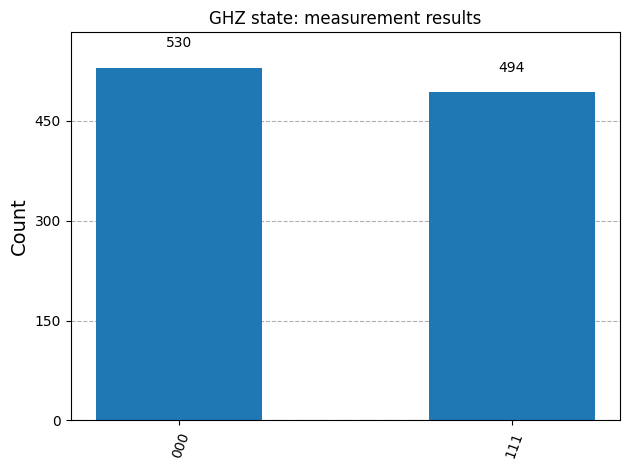

In [7]:
qc_ghz.measure([0, 1, 2], [0, 1, 2])
counts_ghz = simulator.run(transpile(qc_ghz, simulator), shots=1024).result().get_counts()
print("GHZ state measurement counts:", counts_ghz)
plot_histogram(counts_ghz, title="GHZ state: measurement results")

## Toffoli gate (CCX): a 3-qubit gate

The target qubit flips only if BOTH control qubits are `1`. Here we
set both controls to `1` with X gates first, so we expect the
target to flip.

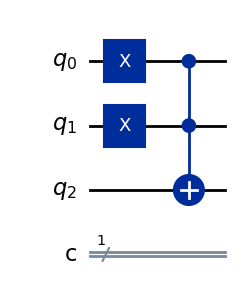

In [8]:
qc_toffoli = QuantumCircuit(3, 1)
qc_toffoli.x(0)          # control 1 = 1
qc_toffoli.x(1)          # control 2 = 1
qc_toffoli.ccx(0, 1, 2)  # target flips only if both controls are 1
qc_toffoli.draw("mpl")

Toffoli gate probabilities: {np.str_('111'): np.float64(1.0)}


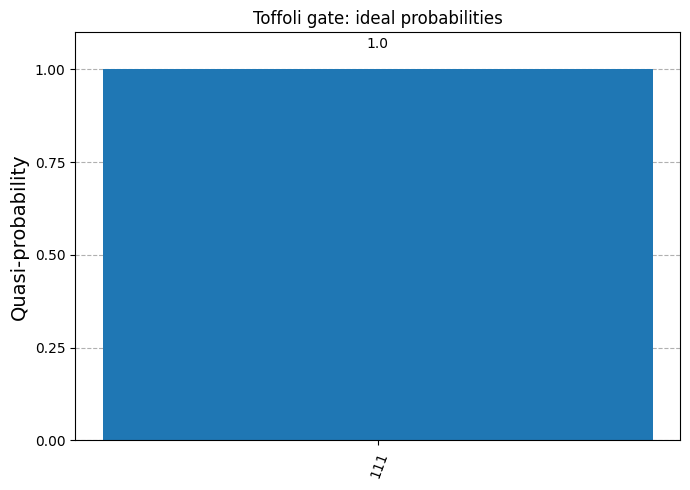

In [9]:
probs_toffoli = Statevector(qc_toffoli).probabilities_dict()
print("Toffoli gate probabilities:", probs_toffoli)
plot_distribution(probs_toffoli, title="Toffoli gate: ideal probabilities")

Toffoli gate measurement counts (target qubit): {'1': 1024}


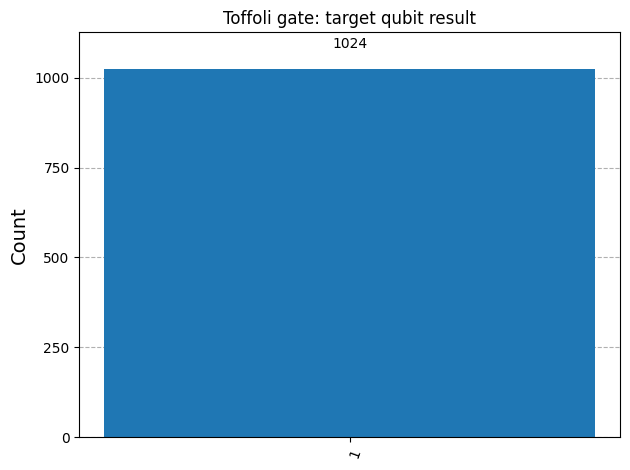

In [10]:
qc_toffoli.measure(2, 0)
counts_toffoli = simulator.run(transpile(qc_toffoli, simulator), shots=1024).result().get_counts()
print("Toffoli gate measurement counts (target qubit):", counts_toffoli)
plot_histogram(counts_toffoli, title="Toffoli gate: target qubit result")

## SWAP gate

Swaps the states of two qubits. Here qubit 0 starts as `|1>` and
qubit 1 starts as `|0>` — after the SWAP, they should trade places.

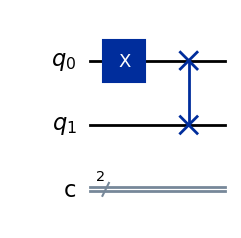

In [11]:
qc_swap = QuantumCircuit(2, 2)
qc_swap.x(0)         # qubit 0 = |1>, qubit 1 = |0>
qc_swap.swap(0, 1)   # after swap: qubit 0 = |0>, qubit 1 = |1>
qc_swap.draw("mpl")

SWAP gate probabilities: {np.str_('10'): np.float64(1.0)}


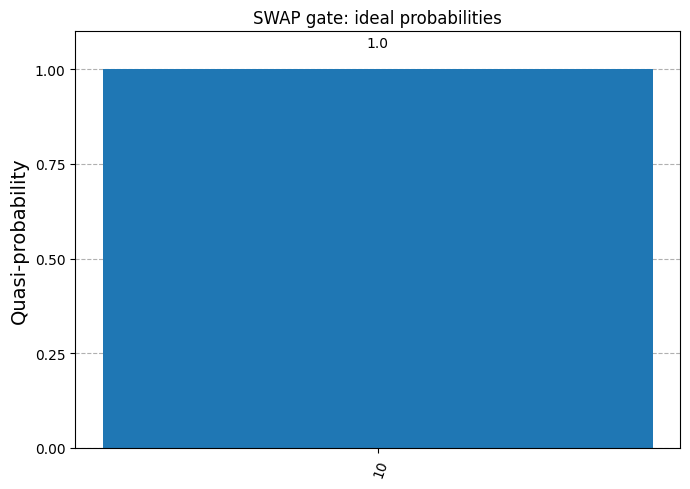

In [12]:
probs_swap = Statevector(qc_swap).probabilities_dict()
print("SWAP gate probabilities:", probs_swap)
plot_distribution(probs_swap, title="SWAP gate: ideal probabilities")

SWAP gate measurement counts: {'10': 1024}


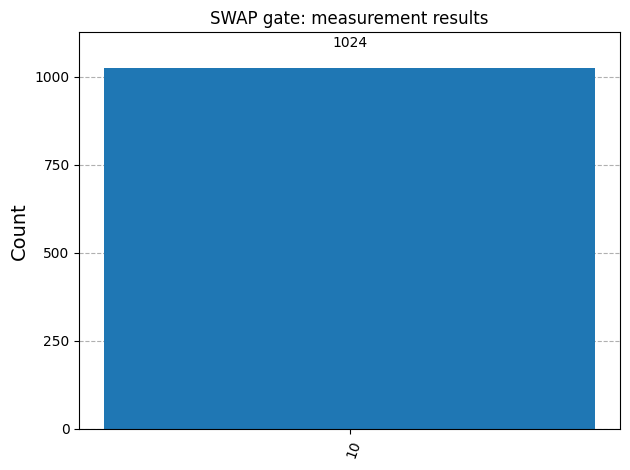

In [13]:
qc_swap.measure([0, 1], [0, 1])
counts_swap = simulator.run(transpile(qc_swap, simulator), shots=1024).result().get_counts()
print("SWAP gate measurement counts:", counts_swap)
plot_histogram(counts_swap, title="SWAP gate: measurement results")